# Filter Evals   
---   
This code looks in the `model_outputs` folder and for each folder, it runs through the various files and creates two outputs:
1) Correct Solutions
2) Incorrect Solutions

In [1]:
import json
from pathlib import Path
from collections import Counter
from utils.parsing import extract_solution, coerce_response
from utils.exceptions import IllegalMoveException

import matplotlib.pyplot as plt

In [2]:
# Toggle whether to write out JSONL files
SAVE_FILES = False

def evaluate_file(fp: Path):
    task = fp.stem.split('_')[0]
    res = {"Correct": 0, "Incorrect": 0, "Thrown Away": 0}
    correct, incorrect, errors = [], [], []
    data = json.load(fp.open())
    for e in data:
        try:
            prompt = e["prompt"]
            resp   = e["model_response"]
            gt     = e["info"]["answer"]

            if task in ("bestmove", "worstmove"):
                answer     = gt["answer"]
                candidates = gt["candidates"]
                pred = coerce_response(extract_solution(resp), "choose_from_n")
                if pred == answer:
                    res["Correct"] += 1
                    correct.append(e)
                elif pred in candidates:
                    res["Incorrect"] += 1
                    incorrect.append(e)
                else:
                    raise IllegalMoveException()

            elif task == "legalmoves":
                pred = coerce_response(extract_solution(resp), "produce_list")
                if set(pred) == set(gt) and len(pred) == len(gt):
                    res["Correct"] += 1
                    correct.append(e)
                else:
                    res["Incorrect"] += 1
                    incorrect.append(e)

            elif task == "predictmove":
                pred = coerce_response(extract_solution(resp), "predict_singlemove")
                if pred in gt:
                    sorted_gt = sorted(gt.items(), key=lambda x: x[1])
                    idx = next(i for i, (m, _) in enumerate(sorted_gt) if m == pred)
                    rank = idx / len(sorted_gt)
                    if rank > 0.7:
                        res["Correct"] += 1
                        correct.append(e)
                    else:
                        res["Incorrect"] += 1
                        incorrect.append(e)
                else:
                    raise IllegalMoveException()

            else:
                # Skip unknown tasks
                continue

        except Exception:
            res["Thrown Away"] += 1
            errors.append(e)

    return task, res, correct, incorrect, errors

base = Path("model_outputs")
for folder in base.iterdir():
    if not folder.is_dir():
        continue

    agg = {"Correct": 0, "Incorrect": 0, "Thrown Away": 0}
    all_corr, all_incorr, all_errs = [], [], []

    for fp in folder.glob("*.json"):
        task, res, corr, incorr, errs = evaluate_file(fp)
        agg["Correct"]     += res["Correct"]
        agg["Incorrect"]   += res["Incorrect"]
        agg["Thrown Away"] += res["Thrown Away"]

        all_corr.extend(corr)
        all_incorr.extend(incorr)
        all_errs.extend(errs)

        if SAVE_FILES:
            # write per-file JSONL
            with (folder / f"{fp.stem}_correct.jsonl").open("w") as f:
                for e in corr:
                    f.write(json.dumps(e) + "\n")
            with (folder / f"{fp.stem}_incorrect.jsonl").open("w") as f:
                for e in incorr:
                    f.write(json.dumps(e) + "\n")
            with (folder / f"{fp.stem}_errors.jsonl").open("w") as f:
                for e in errs:
                    f.write(json.dumps(e) + "\n")

    def avg_len(lst):
        return sum(len(e["model_response"]) for e in lst) / len(lst) if lst else 0

    print(f"{folder.name}: {agg['Correct']} correct, {agg['Incorrect']} incorrect, {agg['Thrown Away']} thrown away")
    print(f"  Avg model_response length (chars): correct={avg_len(all_corr):.1f}, "
          f"incorrect={avg_len(all_incorr):.1f}, errors={avg_len(all_errs):.1f}")

llmchess-llama31-8b-400: 203 correct, 878 incorrect, 519 thrown away
  Avg model_response length (chars): correct=1472.7, incorrect=1481.8, errors=1068.2
llmchess-llama31-8b-sft-mmxl-400: 440 correct, 893 incorrect, 267 thrown away
  Avg model_response length (chars): correct=3068.5, incorrect=3441.3, errors=3451.4
llmchess-llama4-maverick-400: 340 correct, 925 incorrect, 335 thrown away
  Avg model_response length (chars): correct=2930.1, incorrect=3001.3, errors=2755.3
llmchess-qwen25-7b-400: 175 correct, 861 incorrect, 564 thrown away
  Avg model_response length (chars): correct=1150.3, incorrect=1085.9, errors=853.5
llmchess-qwen25-7b-grpo-datamix-2-400: 563 correct, 886 incorrect, 151 thrown away
  Avg model_response length (chars): correct=1531.0, incorrect=1870.2, errors=3362.3
llmchess-qwen25-7b-grpo-mmxl-400: 410 correct, 1018 incorrect, 172 thrown away
  Avg model_response length (chars): correct=3305.9, incorrect=3552.8, errors=5509.1
llmchess-qwen25-7b-sft-dm2-v2-400: 373 c

## Code to plot histogram of move rank provided   
---

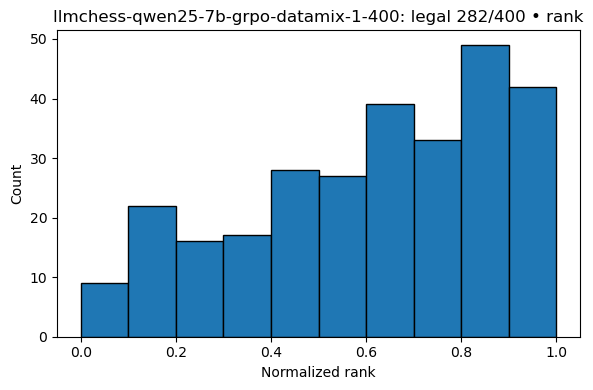

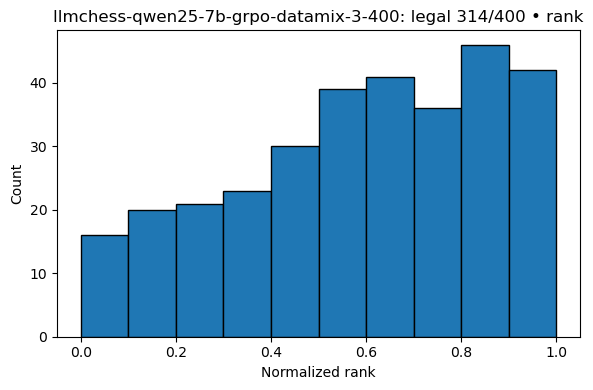

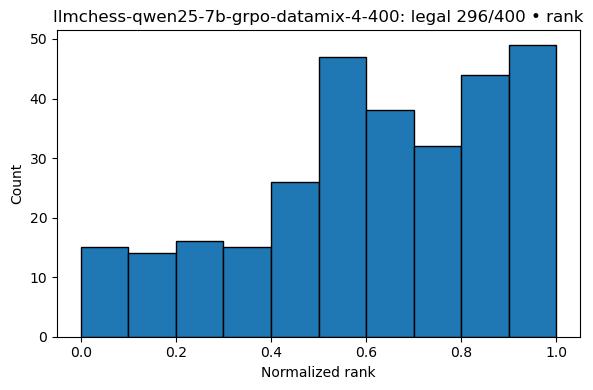

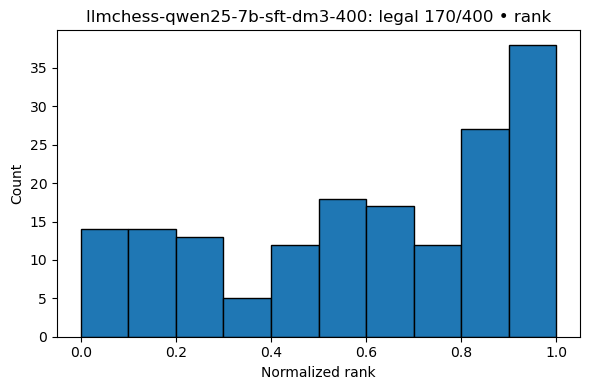

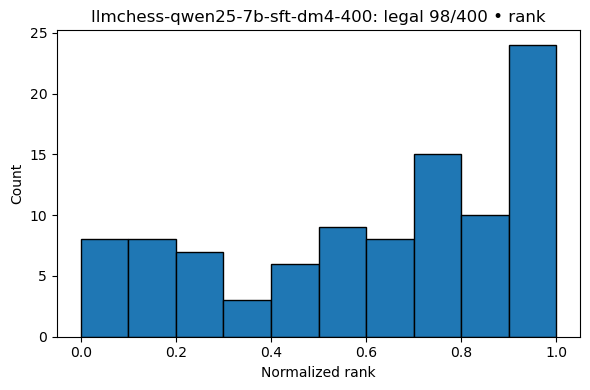

In [3]:
# ================ Configs ====================
BASE_DIR         = Path("model_outputs")
USE_STANDARDIZED = False
# =============================================


for folder in sorted(p for p in BASE_DIR.iterdir() if p.is_dir()):
    values, legal_cnt, total_cnt = [], 0, 0

    for fp in folder.glob("*.json"):
        if "predictmove" not in fp.stem:
            continue

        for e in json.load(fp.open()):
            total_cnt += 1
            try:
                pred = coerce_response(
                    extract_solution(e["model_response"]),
                    "predict_singlemove"
                )
            except Exception:
                continue   # unparseable -> treated as error

            gt = e["info"]["answer"]          # {move: score, …}
            if pred not in gt:
                continue                       # illegal move

            legal_cnt += 1

            if USE_STANDARDIZED:
                scores = list(gt.values())
                rng = max(scores) - min(scores)
                val = 0.0 if rng == 0 else (gt[pred] - min(scores)) / rng
            else:  # rank‑based (0 = best)
                rank = sorted(gt, key=gt.get).index(pred)
                val  = rank / (len(gt) - 1) if len(gt) > 1 else 0.0

            values.append(val)

    # ── one histogram per folder ──────────────────────────────────────
    plt.figure(figsize=(6, 4))
    plt.hist(values, bins=10, range=(0, 1), edgecolor="black")
    mode = "standardized score" if USE_STANDARDIZED else "rank"
    plt.title(f"{folder.name}: legal {legal_cnt}/{total_cnt} • {mode}")
    plt.xlabel("Standardized value" if USE_STANDARDIZED else "Normalized rank")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

In [2]:
# ================ Configs ====================
BASE_DIR = Path("model_outputs")
# =============================================

for folder in sorted(p for p in BASE_DIR.iterdir() if p.is_dir()):
    move_counts = Counter()
    legal_cnt = 0
    total_cnt = 0

    for fp in folder.glob("*.json"):
        if "predictmove" not in fp.stem:
            continue

        data = json.load(fp.open())
        for e in data:
            total_cnt += 1
            try:
                pred = coerce_response(
                    extract_solution(e["model_response"]),
                    "predict_singlemove"
                )
            except Exception:
                continue  # unparseable

            gt = e["info"]["answer"]  # {move: score, ...}
            if pred not in gt:
                continue  # illegal move

            legal_cnt += 1
            move_counts[pred] += 1

    # ── print move frequency table for this folder ─────────────────────
    print(f"\n=== {folder.name} ===")
    print(f"Legal predictions: {legal_cnt}/{total_cnt} total examples")
    if move_counts:
        colw = max(len(mv) for mv in move_counts)
        print(f"{'Move':<{colw}}  Count")
        print("-" * (colw + 8))
        prints = 0
        for mv, cnt in move_counts.most_common():
            print(f"{mv:<{colw}}  {cnt}")
            prints += 1
            if prints > 10:
                break
        print(f"- Unique legal moves predicted: {len(move_counts)}")
    else:
        print("No legal, parseable predictions.")


=== eval-qwen25-7b-sftdm6-drgrpo-dm6-400 ===
Legal predictions: 277/400 total examples
Move  Count
------------
a8b8  68
a1b1  40
f1e1  30
f8e8  13
b8a8  12
c1b1  9
b1d2  8
e1d1  6
e8d8  5
d1c1  5
b8d7  5
- Unique legal moves predicted: 62

=== llmchess-testdifficulty-qwen25-7b-1k_fixedids ===
Legal predictions: 0/1000 total examples
No legal, parseable predictions.

=== llmchess-testdifficulty-qwen25-7b-sft-dm6-1000_fixedids ===
Legal predictions: 0/1000 total examples
No legal, parseable predictions.


# Analyze NTP Play Move

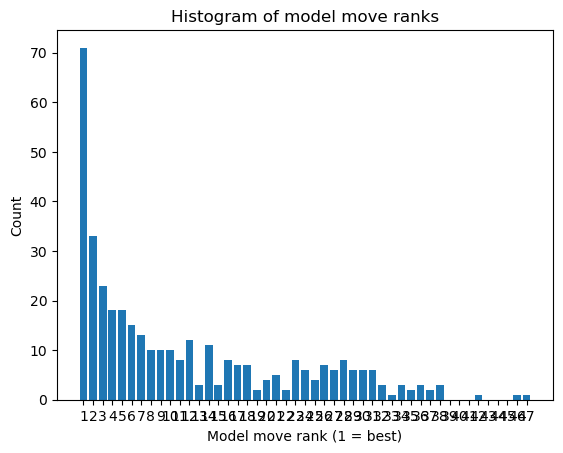

Rank counts: {1: 71, 2: 33, 3: 23, 4: 18, 5: 18, 6: 15, 7: 13, 8: 10, 9: 10, 10: 10, 11: 8, 12: 12, 13: 3, 14: 11, 15: 3, 16: 8, 17: 7, 18: 7, 19: 2, 20: 4, 21: 5, 22: 2, 23: 8, 24: 6, 25: 4, 26: 7, 27: 6, 28: 8, 29: 6, 30: 6, 31: 6, 32: 3, 33: 1, 34: 3, 35: 2, 36: 3, 37: 2, 38: 3, 42: 1, 46: 1, 47: 1}
Model move not present in answer set for 30 item(s).

Top 10 model responses:
g8f6	9
d7d5	7
g1f3	6
d8b6	5
h7h6	5
d5c4	5
b1c3	4
c3a4	4
f1d3	4
g2f3	4


In [4]:
# --- Set your input file path here ---
JSON_PATH = "model_outputs/ntp-playmove_eval_400_all_20250804-233341.json"

# Load data
with open(JSON_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

found_ranks = []
not_found = 0
model_moves_counter = Counter()

for entry in data:
    answers = entry.get("info", {}).get("answer", {})
    if not answers:
        continue

    # Sort answers by score (descending) and map move -> rank (1 = best)
    sorted_moves = sorted(answers.items(), key=lambda kv: kv[1], reverse=True)
    rank_by_move = {m.lower(): i + 1 for i, (m, _) in enumerate(sorted_moves)}

    # Normalize model response
    model_move = str(entry.get("model_response", "")).strip().lower()
    if model_move:
        model_moves_counter[model_move] += 1

    rank = rank_by_move.get(model_move)
    if rank is not None:
        found_ranks.append(rank)
    else:
        not_found += 1

# Summary
rank_counts = Counter(found_ranks)

# Plot histogram of ranks
if found_ranks:
    max_rank = max(found_ranks)
    plt.figure()
    plt.hist(found_ranks, bins=range(1, max_rank + 2), align="left", rwidth=0.8)
    plt.xticks(range(1, max_rank + 1))
    plt.xlabel("Model move rank (1 = best)")
    plt.ylabel("Count")
    plt.title("Histogram of model move ranks")
    plt.show()
else:
    print("No ranks to plot.")

# Print rank counts and misses
print("Rank counts:", dict(sorted(rank_counts.items())))
if not_found:
    print(f"Model move not present in answer set for {not_found} item(s).")

# Top 10 most commonly played moves by the model
if model_moves_counter:
    print("\nTop 10 model responses:")
    for move, count in model_moves_counter.most_common(10):
        print(f"{move}\t{count}")
else:
    print("No model responses found.")